# HW 1 — Network Intrusion Detection

## UNSW-NB15 Dataset

Разведочный анализ данных сетевого трафика
для задачи обнаружения сетевых атак.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train = pd.read_csv("../data/UNSW_NB15_training-set.csv")

In [5]:
test = pd.read_csv("../data/UNSW_NB15_testing-set.csv")

In [6]:
train.shape

(175341, 45)

In [7]:
test.shape

(82332, 45)

In [8]:
train.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [10]:
train["label"].value_counts()

label
1    119341
0     56000
Name: count, dtype: int64

In [11]:
train["label"].value_counts(normalize=True) * 100

label
1    68.062233
0    31.937767
Name: proportion, dtype: float64

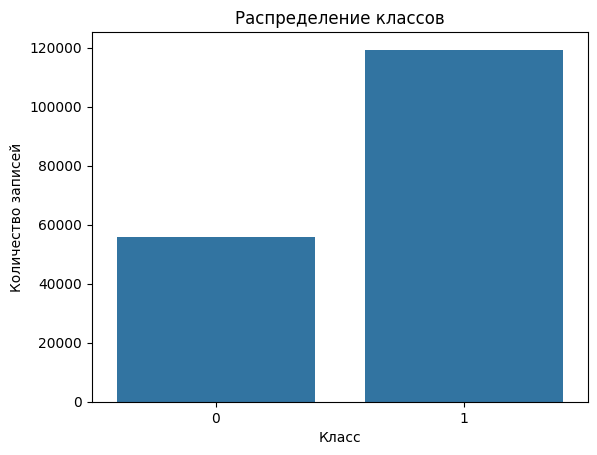

In [12]:
sns.countplot(data=train, x="label")

plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество записей")

plt.show()

### Распределение целевой переменной

В тренировочной выборке представлено 175 341 сетевое соединение.
Из них 119 341 (68,06%) относятся к атакам, а 56 000 (31,94%) —
к нормальному трафику.

Таким образом, наблюдается дисбаланс классов: атакующие соединения
представлены примерно в 2,1 раза чаще, чем нормальные.

Данный дисбаланс необходимо учитывать при дальнейшем построении
модели классификации. В частности, одной Accuracy будет недостаточно
для оценки качества модели, поэтому будут использоваться Precision,
Recall и F1-score.

In [13]:
train["attack_cat"].value_counts()

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

In [14]:
train["attack_cat"].value_counts(normalize=True) * 100

attack_cat
Normal            31.937767
Generic           22.812691
Exploits          19.044605
Fuzzers           10.370649
DoS                6.994371
Reconnaissance     5.983198
Analysis           1.140635
Backdoor           0.995774
Shellcode          0.646169
Worms              0.074141
Name: proportion, dtype: float64

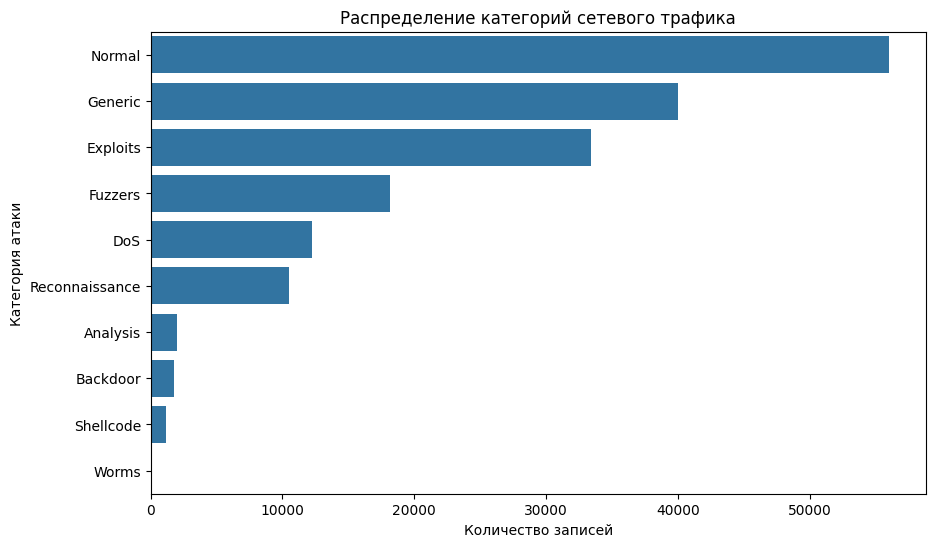

In [15]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=train,
    y="attack_cat",
    order=train["attack_cat"].value_counts().index
)

plt.title("Распределение категорий сетевого трафика")
plt.xlabel("Количество записей")
plt.ylabel("Категория атаки")

plt.show()

# график attack_cat — код выше

In [16]:
train["proto"].value_counts().head(15)

proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
ipv6        201
mobile      201
pim         201
swipe       201
sun-nd      201
rsvp        200
sep         193
Name: count, dtype: int64

In [17]:
train["state"].value_counts()

state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64

In [18]:
pd.crosstab(train["proto"], train["label"])

label,0,1
proto,,
3pc,0,100
a/n,0,100
aes-sp3-d,0,100
any,0,300
argus,0,98
...,...,...
wsn,0,100
xnet,0,99
xns-idp,0,99


In [19]:
pd.crosstab(
    train["proto"],
    train["label"],
    normalize="index"
) * 100

label,0,1
proto,,
3pc,0.0,100.0
a/n,0.0,100.0
aes-sp3-d,0.0,100.0
any,0.0,100.0
argus,0.0,100.0
...,...,...
wsn,0.0,100.0
xnet,0.0,100.0
xns-idp,0.0,100.0


In [20]:
pd.crosstab(
    train["state"],
    train["label"],
    normalize="index"
) * 100

label,0,1
state,,
CON,91.993613,8.006387
ECO,100.000000,0.000000
FIN,47.767427,52.232573
INT,6.946217,93.053783
PAR,100.000000,0.000000
REQ,46.459066,53.540934
RST,85.542169,14.457831
URN,100.000000,0.000000
no,100.000000,0.000000


In [21]:
proto_stats = pd.crosstab(
    train["proto"],
    train["label"],
    margins=True
)

proto_stats

label,0,1,All
proto,,,
3pc,0,100,100
a/n,0,100,100
aes-sp3-d,0,100,100
any,0,300,300
argus,0,98,98
...,...,...,...
xnet,0,99,99
xns-idp,0,99,99
xtp,0,100,100


In [22]:
top_protocols = train["proto"].value_counts().head(10).index

pd.crosstab(
    train.loc[train["proto"].isin(top_protocols), "proto"],
    train.loc[train["proto"].isin(top_protocols), "label"],
    normalize="index"
) * 100

label,0,1
proto,,
any,0.000000,100.000000
arp,100.000000,0.000000
gre,0.000000,100.000000
ipv6,0.000000,100.000000
mobile,0.000000,100.000000
ospf,2.466281,97.533719
sctp,0.000000,100.000000
tcp,48.934281,51.065719
udp,21.999589,78.000411


Распределение классов зависит от используемого сетевого протокола. Для TCP доли нормального и атакующего трафика близки к равным (48,93% и 51,07%), тогда как для UDP доля атак составляет 78%. Для некоторых протоколов в данной выборке наблюдается практически полное преобладание одного из классов. Это показывает, что `proto` может содержать полезную информацию для классификации, однако для редких протоколов полученные соотношения необходимо интерпретировать с осторожностью из-за небольшого количества наблюдений.

In [23]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,175341.0,8.767100e+04,5.061673e+04,1.0,43836.000000,87671.000000,1.315060e+05,1.753410e+05
dur,175341.0,1.359389e+00,6.480249e+00,0.0,0.000008,0.001582,6.680690e-01,5.999999e+01
spkts,175341.0,2.029866e+01,1.368876e+02,1.0,2.000000,2.000000,1.200000e+01,9.616000e+03
dpkts,175341.0,1.896959e+01,1.102583e+02,0.0,0.000000,2.000000,1.000000e+01,1.097400e+04
sbytes,175341.0,8.844844e+03,1.747656e+05,28.0,114.000000,430.000000,1.418000e+03,1.296523e+07
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.000000,164.000000,1.102000e+03,1.465555e+07
rate,175341.0,9.540619e+04,1.654010e+05,0.0,32.786140,3225.806520,1.250000e+05,1.000000e+06
sttl,175341.0,1.795470e+02,1.029400e+02,0.0,62.000000,254.000000,2.540000e+02,2.550000e+02
dttl,175341.0,7.960957e+01,1.105069e+02,0.0,0.000000,29.000000,2.520000e+02,2.540000e+02
sload,175341.0,7.345403e+07,1.883574e+08,0.0,13053.338870,879674.750000,8.888889e+07,5.988000e+09


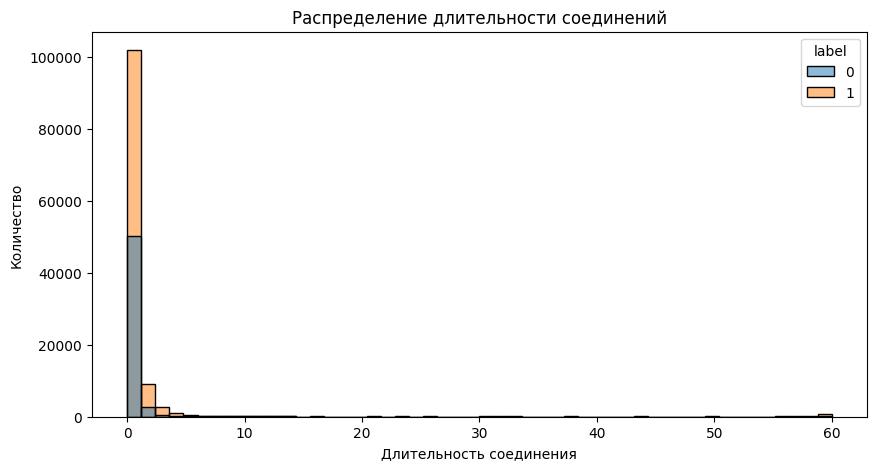

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=train,
    x="dur",
    hue="label",
    bins=50
)

plt.title("Распределение длительности соединений")
plt.xlabel("Длительность соединения")
plt.ylabel("Количество")

plt.show()

In [25]:
train.groupby("label")["dur"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
label,,,,
0,1.017177,0.038602,0.0,59.999989
1,1.519969,0.000009,0.0,59.999046


Признак `dur` имеет сильно скошенное распределение. Медианная длительность атакующих соединений составляет около `0,000009` с, тогда как для нормальных соединений — около `0,0386` с. При этом средняя длительность атакующих соединений выше (`1,52` с против `1,02` с), что может быть связано с наличием отдельных соединений с большой длительностью. Таким образом, среднее значение не полностью характеризует распределение `dur`, и для его анализа необходимо учитывать медиану и выбросы.

In [26]:
train.groupby("label")["sbytes"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
label,,,,
0,4105.702929,1470.0,28,338718
1,11068.655357,200.0,60,12965233


Признак `sbytes` имеет существенно различающиеся распределения для нормального и атакующего трафика. Медианное значение для атакующих соединений составляет `200` байт против `1470` байт для нормального трафика, однако среднее значение для атак выше из-за наличия соединений с очень большим объёмом переданных данных. Максимальное значение `sbytes` для атак достигает примерно 13 млн байт.

In [27]:
features = [
    "dur",
    "spkts",
    "dpkts",
    "sbytes",
    "dbytes",
    "rate",
    "sttl",
    "dttl"
]

train.groupby("label")[features].mean().T

label,0,1
dur,1.017177,1.519969
spkts,30.725482,15.405946
dpkts,38.057696,10.012619
sbytes,4105.702929,11068.655357
dbytes,31049.463143,7364.456256
rate,13799.312118,133699.690589
sttl,75.445982,228.395732
dttl,64.276304,86.804602


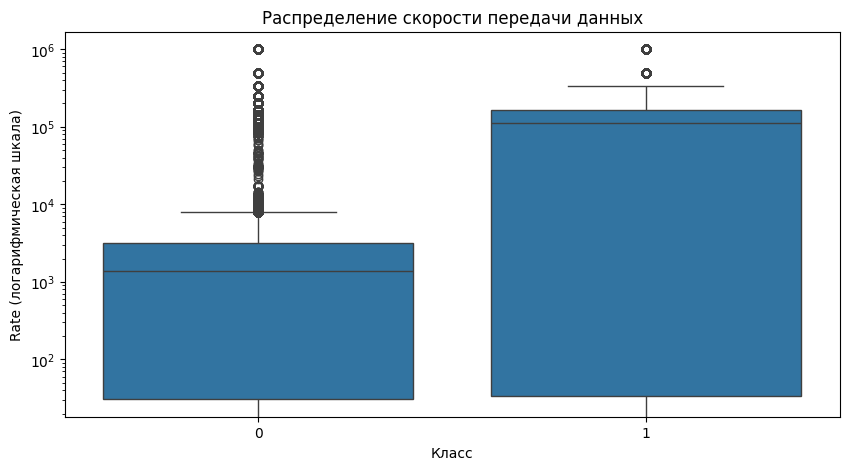

In [29]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=train,
    x="label",
    y="rate"
)

plt.yscale("log")

plt.title("Распределение скорости передачи данных")
plt.xlabel("Класс")
plt.ylabel("Rate (логарифмическая шкала)")

plt.show()

Признак `rate` демонстрирует заметное различие между нормальным и атакующим трафиком. Основная часть значений для нормального трафика сосредоточена на значительно меньших значениях, тогда как распределение атакующего трафика смещено в сторону высоких значений. Это согласуется с различием средних значений (`13 799` для нормального трафика и `133 700` для атакующего). Таким образом, `rate` потенциально является информативным признаком для классификации сетевого трафика.

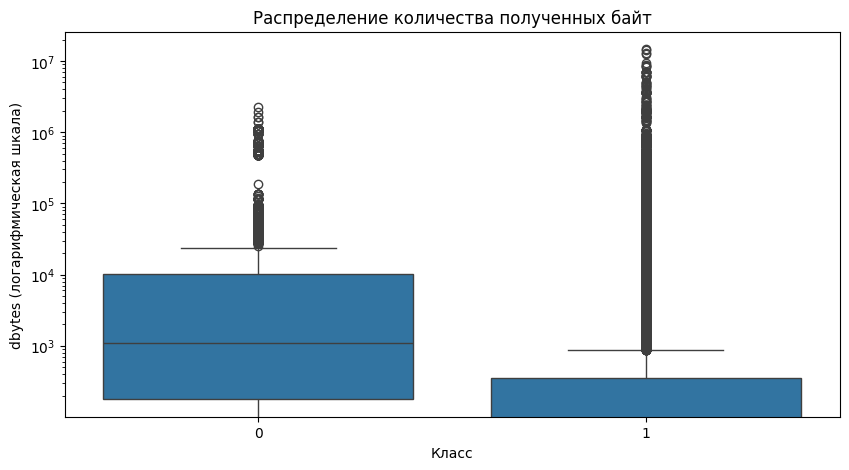

In [30]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=train,
    x="label",
    y="dbytes"
)

plt.yscale("log")

plt.title("Распределение количества полученных байт")
plt.xlabel("Класс")
plt.ylabel("dbytes (логарифмическая шкала)")

plt.show()

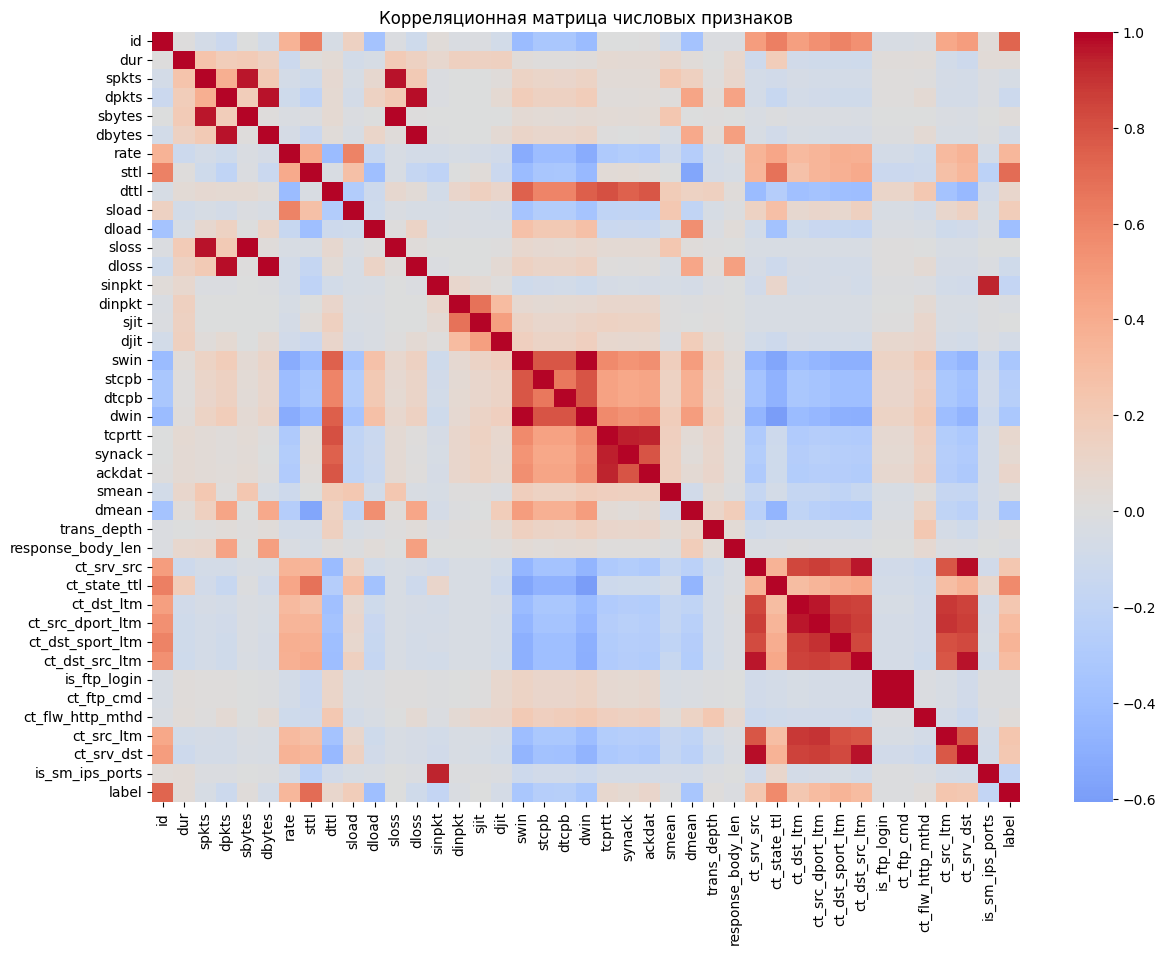

In [31]:
corr = train.select_dtypes(include="number").corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Корреляционная матрица числовых признаков")
plt.show()

### Корреляционный анализ

Корреляционная матрица показывает несколько групп взаимосвязанных
числовых признаков. Наиболее заметный кластер образуют признаки,
характеризующие количество пакетов, объём переданных данных и потери:
`spkts`, `dpkts`, `sbytes`, `dbytes`, `sloss` и `dloss`.

Отдельные группы взаимосвязанных признаков наблюдаются среди
TCP-характеристик (`stcpb`, `dtcpb`, `tcprtt`, `synack`, `ackdat` и др.)
и среди счётчиков соединений `ct_*`.

Таким образом, некоторые признаки содержат частично схожую информацию.
Это необходимо учитывать на следующих этапах построения модели,
поскольку сильная корреляция между признаками может приводить
к избыточности признакового пространства.

При этом корреляция показывает статистическую взаимосвязь признаков
и не означает наличие причинно-следственной зависимости.

In [32]:
train["service"].value_counts().head(15)

service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64

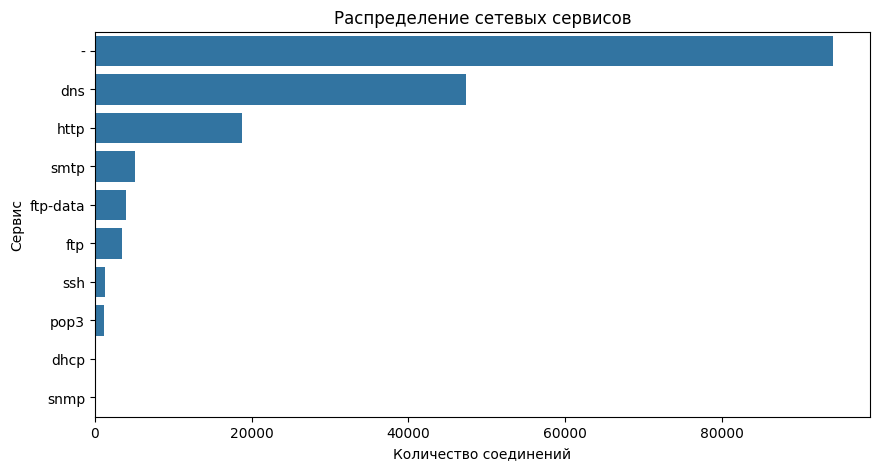

In [33]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=train,
    y="service",
    order=train["service"].value_counts().head(10).index
)

plt.title("Распределение сетевых сервисов")
plt.xlabel("Количество соединений")
plt.ylabel("Сервис")
plt.show()

In [34]:
service_label = pd.crosstab(
    train["service"],
    train["label"],
    normalize="index"
) * 100

service_label.sort_values(1, ascending=False)

label,0,1
service,,
dhcp,0.000000,100.000000
ssl,0.000000,100.000000
irc,0.000000,100.000000
pop3,0.361991,99.638009
snmp,1.250000,98.750000
dns,15.843447,84.156553
radius,16.666667,83.333333
http,28.562273,71.437727
smtp,31.217873,68.782127


### Связь сетевого сервиса с классом трафика

Распределение классов существенно различается для разных значений
признака `service`. Например, для `dns` доля атакующего трафика
составляет 84,16%, для `http` — 71,44%, а для `ssh` — только 0,84%.

Таким образом, признак `service` потенциально содержит полезную
информацию для классификации сетевого трафика.

При этом для редких сервисов результаты необходимо интерпретировать
с осторожностью. Например, значения `irc`, `radius`, `ssl` и `dhcp`
представлены небольшим количеством наблюдений, поэтому их почти
полное соответствие одному классу не позволяет делать надёжные
обобщения.

In [35]:
service_stats = train.groupby("service").agg(
    count=("label", "size"),
    attack_rate=("label", "mean")
)

service_stats["attack_rate"] *= 100

service_stats.sort_values("attack_rate", ascending=False)

,count,attack_rate
service,,
dhcp,94,100.000000
ssl,56,100.000000
irc,25,100.000000
pop3,1105,99.638009
snmp,80,98.750000
dns,47294,84.156553
radius,12,83.333333
http,18724,71.437727
smtp,5058,68.782127


### Связь сетевого сервиса с классом трафика

Распределение классов заметно различается в зависимости от значения
признака `service`. Для часто встречающихся сервисов наблюдаются
существенные различия: например, для `dns` доля атак составляет
84,16% при 47 294 наблюдениях, для `http` — 71,44% при 18 724
наблюдениях, а для `ssh` — только 0,84% при 1 302 наблюдениях.

Это показывает, что `service` потенциально является информативным
признаком для классификации сетевого трафика.

Для редких сервисов результаты необходимо интерпретировать
с осторожностью. Например, значения `irc` и `radius` имеют всего
25 и 12 наблюдений соответственно, поэтому их высокая доля атак
не позволяет делать надёжные обобщения.

## Общие выводы EDA

В ходе разведочного анализа датасета UNSW-NB15 были исследованы
распределение целевой переменной, категориальные и числовые признаки,
а также корреляции между числовыми признаками.

В тренировочной выборке наблюдается дисбаланс классов: 68,06% записей
относятся к атакам и 31,94% — к нормальному трафику. Поэтому при
дальнейшем построении модели одной Accuracy будет недостаточно,
и необходимо учитывать Precision, Recall и F1-score. Для задачи
обнаружения атак особенно важным является Recall, поскольку
пропуск атаки может иметь более серьёзные последствия, чем
ложное срабатывание.

Анализ категориальных признаков показал, что распределение классов
зависит от протокола, состояния соединения и используемого сервиса.
Например, для состояния `INT` доля атак составляет 93,05%, тогда как
для `CON` — 8,01%. Для часто встречающихся сервисов также наблюдаются
значительные различия в доле атак: для `dns` она составляет 84,16%,
а для `ssh` — только 0,84%.

Числовые признаки также демонстрируют различия между нормальным
и атакующим трафиком. В частности, атакующий трафик характеризуется
более высокими значениями `rate`, меньшими медианными значениями
некоторых признаков объёма и количества пакетов, а также выраженной
асимметрией распределений. Для ряда признаков наблюдаются значительные
выбросы, поэтому при дальнейшем моделировании необходимо учитывать
форму распределений и масштаб признаков.

Корреляционный анализ выявил несколько групп взаимосвязанных
признаков, включая признаки количества пакетов и объёмов данных,
TCP-характеристики и счётчики `ct_*`. Это указывает на наличие
избыточной информации между некоторыми признаками, что необходимо
учитывать при построении модели.

В результате EDA установлено, что датасет содержит признаки,
потенциально информативные для обнаружения сетевых атак, однако
распределения классов, выбросы, редкие категории и корреляции между
признаками необходимо учитывать на следующих этапах построения
и оценки модели классификации.